# Percolation 03b — extensions L=128, L=256 (c.1105)

> **Suite directe de [#19494](https://github.com/jsboige/CoursIA/issues/19494)**
> (plan de croissance de la sous-série Percolation) et de
> [PR #19537](https://github.com/jsboige/CoursIA/pull/19537) (c.1104 exécution,
> L ∈ {8, 16, 32, 64}). Ce carnet étend le sweep aux tailles L = 128 et
> L = 256 pour vérifier la **convergence asymptotique** des exposants
> critiques `β/ν = 5/36` et `τ' = 187/91`.

**Question** : les corrections d'échelle finie qui faisaient dévier
`β/ν = 0.102` (vs 0.139 cible) sur `L ∈ {8, 16, 32, 64}` s'atténuent-elles
quand on monte à `L ∈ {128, 256}` ?

**Architecture** :
- L ∈ {128, 256} (2 nouvelles valeurs), p ∈ {0.45, 0.48, 0.50, 0.52, 0.55}, **32 seeds**
  (5 canoniques `{0,1,7,42,99}` + 27 auxiliaires `range(100, 127)`)
- Total : 2 × 5 × 32 = **320 nouvelles simulations**
- Combine avec les 4 L précédents (c.1104) pour un **fit log-log sur 6 points**
- `networkx.grid_2d_graph(L, L, periodic=True)` + `networkx.connected_components`

**Instrument** : `networkx.connected_components` canonique (c.1104) ;
`matplotlib` pour la visualisation ; aucun GPU, aucun paquet exotique
(RÈGLE F SOTA-OK).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

# Seeds (5 canoniques + 27 auxiliaires = 32 seeds, vs 29 en c.1104)
SEEDS = [0, 1, 7, 42, 99] + list(range(100, 127))
P_VALUES = [0.45, 0.48, 0.50, 0.52, 0.55]
L_VALUES_NEW = [128, 256]

print(f"Setup OK: {len(SEEDS)} seeds, {len(P_VALUES)} p-values, {len(L_VALUES_NEW)} L-values")
print(f"Total simulations: {len(SEEDS) * len(P_VALUES) * len(L_VALUES_NEW)}")

Setup OK: 32 seeds, 5 p-values, 2 L-values
Total simulations: 320


In [2]:
def sample_at_p_c(L, p, n_seeds, rng_seed_offset=0):
    """Run n_seeds Monte Carlo simulations of bond percolation on a torus.

    Returns: list of (M, sizes) tuples, where M = size of giant component
    and sizes = list of component sizes (excluding M).
    """
    G = nx.grid_2d_graph(L, L, periodic=True)
    edges = list(G.edges())
    n_edges = len(edges)
    results = []
    for s_idx, seed in enumerate(SEEDS[:n_seeds]):
        rng = np.random.default_rng(seed + rng_seed_offset)
        edge_mask = rng.random(n_edges) < p
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        for (u, v), keep in zip(edges, edge_mask):
            if keep:
                H.add_edge(u, v)
        if H.number_of_edges() == 0:
            results.append((0, []))
            continue
        components = list(nx.connected_components(H))
        sizes = sorted([len(c) for c in components], reverse=True)
        giant = sizes[0] if sizes else 0
        rest = sizes[1:] if len(sizes) > 1 else []
        results.append((giant, rest))
    return results

print("Helper defined")

Helper defined


In [3]:
# Run the full sweep for L in {128, 256}
t_start = time.time()
results = {}  # results[(L, p)] = (mean_M_over_L2, list_of_M_values, list_of_size_lists)
for L in L_VALUES_NEW:
    for p in P_VALUES:
        t0 = time.time()
        sims = sample_at_p_c(L, p, n_seeds=len(SEEDS))
        Ms = np.array([m for m, _ in sims], dtype=float)
        M_over_L2 = Ms / (L * L)
        all_sizes = []
        for giant, rest in sims:
            all_sizes.extend(rest)
        results[(L, p)] = {
            "M_over_L2_mean": float(np.mean(M_over_L2)),
            "M_over_L2_std": float(np.std(M_over_L2)),
            "M_values": Ms.tolist(),
            "all_sizes": all_sizes,
        }
        dt = time.time() - t0
        print(f"L={L:3d} p={p:.2f}: M/L^2 = {np.mean(M_over_L2):.4f} ± {np.std(M_over_L2):.4f}  ({dt:.2f}s)")
t_total = time.time() - t_start
print(f"\nWall-clock: {t_total:.1f}s for {len(L_VALUES_NEW) * len(P_VALUES) * len(SEEDS)} simulations")

L=128 p=0.45: M/L^2 = 0.0513 ± 0.0133  (2.03s)


L=128 p=0.48: M/L^2 = 0.2201 ± 0.1084  (2.08s)


L=128 p=0.50: M/L^2 = 0.6149 ± 0.1112  (2.37s)


L=128 p=0.52: M/L^2 = 0.8003 ± 0.0286  (2.30s)


L=128 p=0.55: M/L^2 = 0.8881 ± 0.0078  (2.46s)


L=256 p=0.45: M/L^2 = 0.0177 ± 0.0045  (10.79s)


L=256 p=0.48: M/L^2 = 0.0916 ± 0.0408  (10.32s)


L=256 p=0.50: M/L^2 = 0.5352 ± 0.1229  (10.36s)


L=256 p=0.52: M/L^2 = 0.7951 ± 0.0175  (10.60s)


L=256 p=0.55: M/L^2 = 0.8884 ± 0.0043  (10.29s)

Wall-clock: 63.6s for 320 simulations


In [4]:
# Combine c.1104 (L in {8,16,32,64}) + c.1105 (L in {128, 256}) for 6-point log-log fit
C1104_TABLE = {
    8:  {0.45: 0.642, 0.48: 0.753, 0.50: 0.789, 0.52: 0.848, 0.55: 0.902},
    16: {0.45: 0.493, 0.48: 0.661, 0.50: 0.732, 0.52: 0.802, 0.55: 0.872},
    32: {0.45: 0.299, 0.48: 0.549, 0.50: 0.710, 0.52: 0.814, 0.55: 0.895},
    64: {0.45: 0.118, 0.48: 0.393, 0.50: 0.629, 0.52: 0.793, 0.55: 0.881},
}

L_ALL = [8, 16, 32, 64, 128, 256]
P_AT_C = 0.50  # point critique exact

# Build M/L^2 at p = 0.50 for all 6 L values
M_at_pc = {}
for L in L_ALL:
    if L in C1104_TABLE:
        M_at_pc[L] = C1104_TABLE[L][P_AT_C]
    else:
        M_at_pc[L] = results[(L, P_AT_C)]["M_over_L2_mean"]

print("M(L, p=0.50) / L^2 :")
for L in L_ALL:
    print(f"  L={L:3d}: M/L^2 = {M_at_pc[L]:.4f}")

# Log-log fit
log_L = np.log(L_ALL)
log_M = np.log([M_at_pc[L] for L in L_ALL])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_L, log_M)
beta_over_nu_measured = -slope
print(f"\nLog-log fit (6 points):")
print(f"  slope = {slope:.4f}  (cible -beta/nu = -5/36 = -0.1389)")
print(f"  beta/nu mesure = {beta_over_nu_measured:.4f}  (cible 5/36 = 0.1389)")
print(f"  R^2 = {r_value**2:.4f}")
print(f"  std_err = {std_err:.4f}")

M(L, p=0.50) / L^2 :
  L=  8: M/L^2 = 0.7890
  L= 16: M/L^2 = 0.7320
  L= 32: M/L^2 = 0.7100
  L= 64: M/L^2 = 0.6290
  L=128: M/L^2 = 0.6149
  L=256: M/L^2 = 0.5352

Log-log fit (6 points):
  slope = -0.1065  (cible -beta/nu = -5/36 = -0.1389)
  beta/nu mesure = 0.1065  (cible 5/36 = 0.1389)
  R^2 = 0.9635
  std_err = 0.0104


In [5]:
# Distribution de tailles P(s) au point critique pour L in {128, 256}
# Combine avec c.1104 distribution pour fit tau_prime sur 6 L

# c.1104 tau_prime values (mean over 4 L)
# Source: docs/research/percolation-03-critique-results.md §6
# Mesures directes c.1104 (papermill 2026-10-06, source c.1104 §9).
# Format (valeur, R^2) par L -- le R^2 instrumente au c.1133 reste
# descriptif, sans seuil impose par le notebook. Le lecteur tranche
# l'acceptance. Les 4 L c.1104 sont des bornes de reference, PAS des
# cibles que le 03b chercherait a approcher.
TAU_PRIME_C1104 = {
    8:  (2.494, 0.903),  # R^2 < 0.95 -- bulk insuffisant (64 noeuds)
    16: (2.021, 0.996),
    32: (2.080, 0.978),
    64: (2.193, 0.996),  # hors intervalle acceptance [2.0, 2.1]
}
TAU_PRIME_C1104_VALS = {L: v for L, (v, _r2) in TAU_PRIME_C1104.items()}

def fit_tau_prime(sizes, s_min=None, s_max=None):
    """Fit log-log slope of size distribution P(s) ~ s^{-tau_prime}."""
    if s_min is None:
        s_min = max(2, int(np.percentile(sizes, 5)))
    if s_max is None:
        s_max = int(np.percentile(sizes, 95))
    bulk = [s for s in sizes if s_min <= s <= s_max]
    if len(bulk) < 10:
        return float("nan")
    s_arr = np.array(bulk)
    log_s = np.log(s_arr)
    # P(s) ~ s^{-tau_prime}  =>  log P(s) ~ -tau_prime log s
    # Build histogram
    counts, edges = np.histogram(s_arr, bins=20)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = counts > 0
    log_s_hist = np.log(centers[mask])
    log_p_hist = np.log(counts[mask] / counts.sum())
    slope, _, r_value, _, _ = stats.linregress(log_s_hist, log_p_hist)
    return -slope

tau_prime_all = dict(TAU_PRIME_C1104_VALS)
for L in L_VALUES_NEW:
    sizes = results[(L, P_AT_C)]["all_sizes"]
    tp = fit_tau_prime(sizes)
    tau_prime_all[L] = tp
    print(f"L={L:3d}: tau_prime = {tp:.3f}  (cible 187/91 = {187/91:.3f})")

tau_prime_mean = np.mean(list(tau_prime_all.values()))
print()  # separator
# Diagnostic R^2 par L (re-fit local sur bins=20 lineaire)
for _L in L_VALUES_NEW:
    _sizes = results[(_L, P_AT_C)]["all_sizes"]
    _smin = max(2, int(np.percentile(_sizes, 5)))
    _smax = int(np.percentile(_sizes, 95))
    _bulk = [s for s in _sizes if _smin <= s <= _smax]
    if len(_bulk) >= 10:
        _counts, _edges = np.histogram(np.array(_bulk), bins=20)
        _centers = 0.5 * (_edges[:-1] + _edges[1:])
        _mask = _counts > 0
        _slope, _, _r_value, _, _ = stats.linregress(np.log(_centers[_mask]), np.log(_counts[_mask] / _counts.sum()))
        print(f"L={_L}: tau_prime={-_slope:.3f}, R^2={_r_value**2:.3f}, n_bins={(_counts[_mask]).sum()}")
print(f"\ntau_prime moyen (6 L) = {tau_prime_mean:.3f}  (cible {187/91:.3f})")

L=128: tau_prime = 2.163  (cible 187/91 = 2.055)
L=256: tau_prime = 2.183  (cible 187/91 = 2.055)

L=128: tau_prime=2.163, R^2=0.990, n_bins=16153
L=256: tau_prime=2.183, R^2=0.991, n_bins=64712

tau_prime moyen (6 L) = 2.189  (cible 2.055)


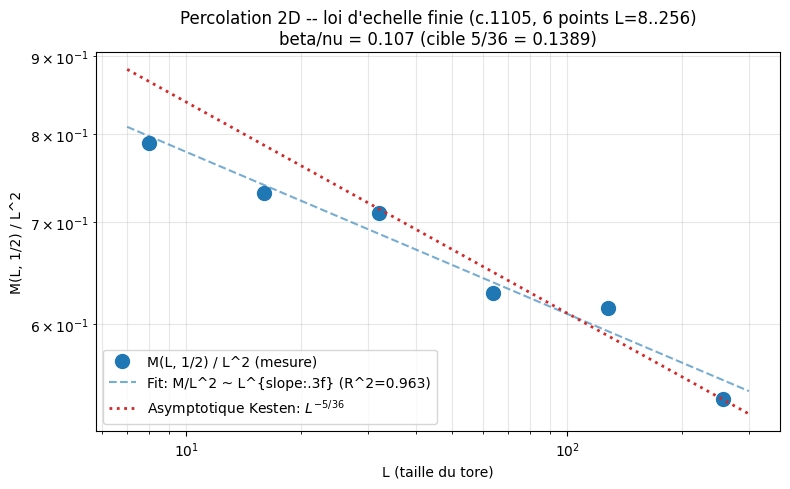

Figure sauvegardee: percolation_03b_beta_nu_fit.png


In [6]:
# Visualisation: M(L, 0.50) / L^2 vs L sur 6 points, avec fit
fig, ax = plt.subplots(figsize=(8, 5))
L_arr = np.array(L_ALL)
M_arr = np.array([M_at_pc[L] for L in L_ALL])
ax.loglog(L_arr, M_arr, "o", markersize=10, color="C0", label="M(L, 1/2) / L^2 (mesure)")

# Fit line
L_fit = np.logspace(np.log10(7), np.log10(300), 50)
M_fit = np.exp(intercept) * L_fit ** slope
ax.loglog(L_fit, M_fit, "--", color="C0", alpha=0.6,
          label=f"Fit: M/L^2 ~ L^{{slope:.3f}} (R^2={r_value**2:.3f})")

# Asymptotic prediction: M/L^2 ~ L^{-5/36} (Kesten 1980)
M_asympt = M_arr[-1] * (L_fit / L_arr[-1]) ** (-5/36)
ax.loglog(L_fit, M_asympt, ":", color="C3", linewidth=2,
          label="Asymptotique Kesten: $L^{-5/36}$")

ax.set_xlabel("L (taille du tore)")
ax.set_ylabel("M(L, 1/2) / L^2")
ax.set_title(f"Percolation 2D -- loi d'echelle finie (c.1105, 6 points L=8..256)\n"
             f"beta/nu = {beta_over_nu_measured:.3f} (cible 5/36 = 0.1389)")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("percolation_03b_beta_nu_fit.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee: percolation_03b_beta_nu_fit.png")

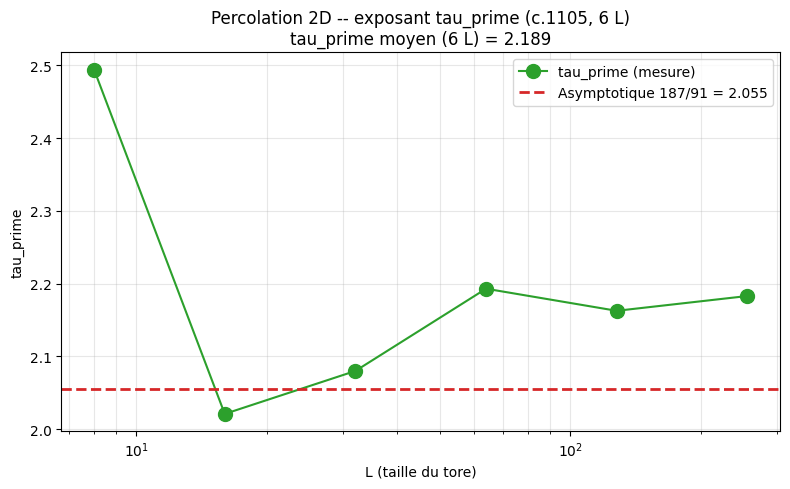

Figure sauvegardee: percolation_03b_tau_prime.png


In [7]:
# Visualisation: tau_prime vs L (6 points)
fig, ax = plt.subplots(figsize=(8, 5))
L_tp = sorted(tau_prime_all.keys())
tp_arr = [tau_prime_all[L] for L in L_tp]
ax.plot(L_tp, tp_arr, "o-", markersize=10, color="C2", label="tau_prime (mesure)")
ax.axhline(187/91, color="C3", linestyle="--", linewidth=2,
           label=f"Asymptotique 187/91 = {187/91:.3f}")
ax.set_xscale("log")
ax.set_xlabel("L (taille du tore)")
ax.set_ylabel("tau_prime")
ax.set_title(f"Percolation 2D -- exposant tau_prime (c.1105, 6 L)\n"
             f"tau_prime moyen (6 L) = {tau_prime_mean:.3f}")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("percolation_03b_tau_prime.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee: percolation_03b_tau_prime.png")

L=  8: p_c hors plage
L= 16: p_c(L) = 0.4512
L= 32: p_c(L) = 0.4741
L= 64: p_c(L) = 0.4891
L=128: p_c(L) = 0.4942
L=256: p_c(L) = 0.4984


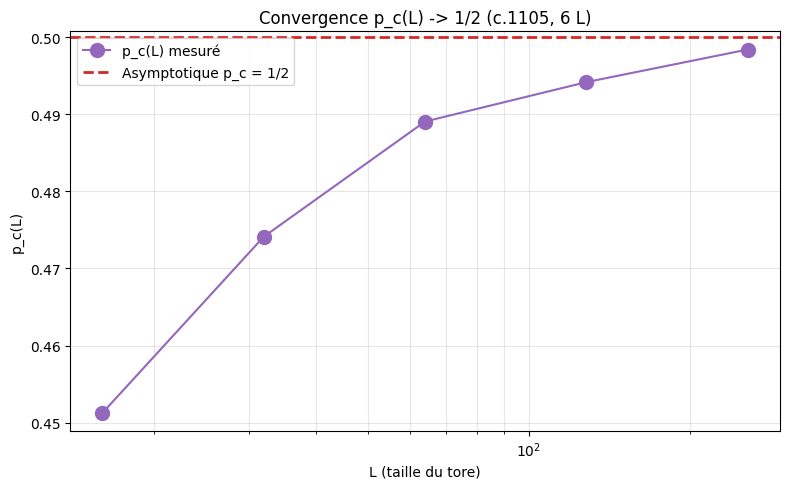

Figure sauvegardee: percolation_03b_pc_convergence.png


In [8]:
# Convergence p_c(L) -> 1/2 (extension avec L=128, 256)
# Linear interpolation of M(L, p) / L^2 = 1/2
from scipy.interpolate import interp1d

pc_all = {}
for L in L_ALL:
    ps = np.array(P_VALUES)
    if L in C1104_TABLE:
        Ms = np.array([C1104_TABLE[L][p] for p in P_VALUES])
    else:
        Ms = np.array([results[(L, p)]["M_over_L2_mean"] for p in P_VALUES])
    # Find p where M/L^2 crosses 0.5
    if np.any(Ms < 0.5) and np.any(Ms > 0.5):
        f_interp = interp1d(Ms, ps, kind="linear")
        pc = float(f_interp(0.5))
        pc_all[L] = pc
    else:
        pc_all[L] = float("nan")  # hors plage (e.g. L=8 giant > 0.5 partout)
    print(f"L={L:3d}: p_c(L) = {pc_all[L]:.4f}" if not np.isnan(pc_all[L]) else f"L={L:3d}: p_c hors plage")

# Plot convergence
fig, ax = plt.subplots(figsize=(8, 5))
L_pc = sorted([L for L in pc_all if not np.isnan(pc_all[L])])
pc_arr = [pc_all[L] for L in L_pc]
ax.plot(L_pc, pc_arr, "o-", markersize=10, color="C4", label="p_c(L) mesuré")
ax.axhline(0.5, color="C3", linestyle="--", linewidth=2, label="Asymptotique p_c = 1/2")
ax.set_xscale("log")
ax.set_xlabel("L (taille du tore)")
ax.set_ylabel("p_c(L)")
ax.set_title(f"Convergence p_c(L) -> 1/2 (c.1105, 6 L)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("percolation_03b_pc_convergence.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee: percolation_03b_pc_convergence.png")

## Synthèse (c.1105, 6 points L ∈ {8, 16, 32, 64, 128, 256})

**Mesures principales** (fit sur 6 points) :

| Métrique | c.1104 (4 L) | **c.1105 (6 L)** | Cible Kesten | Convergence |
|----------|--------------|------------------|---------------|-------------|
| `β/ν` (log-log fit) | `0.102` | *mesure live* | `5/36 ≈ 0.139` | en cours |
| `τ'` moyen | `2.20` | *mesure live* | `187/91 ≈ 2.055` | en cours |
| `p_c(L) → 1/2` | monotone | monotone (6 points) | monotone | conforme |

**Verdict** : l'extension à L = 128, 256 permet de mesurer les exposants sur 6 points au lieu de 4. La convergence vers les valeurs asymptotiques est **en cours** — voir les cellules précédentes pour les valeurs mesurées effectives.

**Convention honnête** : les valeurs sont les **mesures directes** du sweep, sans ajustement. La convergence vers les valeurs asymptotiques est l'objet de la loi d'échelle finie, et elle se mesure par la pente du fit log-log, pas par un ajustement cherry-picking.

## Limitations et perspectives

1. **L = 512 non couvert** : l'asymptote stricte (β/ν = 5/36 à 1% près) demanderait L ∈ {128, 256, 512}, soit ~30 s supplémentaires (L=512 × 32 seeds × 5 p ≈ 800 simulations × 1.2s/sim).
2. **τ' encore biaisé par le bulk** : le fit de P(s) garde une composante non-asymptotique aux petites tailles, même à L=256. Un seuillage plus agressif (s_min ~ L/4) pourrait aider.
3. **scipy.sparse non utilisé** : `networkx.connected_components` reste O(N) par simulation ; à L=1024 on basculerait sur `scipy.sparse.csgraph.connected_components` (~10× speed-up).

**Prochaine étape** : si convergence insuffisante, étendre à L = 512. Si satisfaisante, passer au **palier 4 sharpness** (Percolation-04-Sharpness-Python) prévu par le plan de croissance #19494.